In [ ]:
import numpy as np
import pandas as pd
import pyodbc

db_yolu = r""
db_yolu1 = db_yolu+r"\14_11_2011.mdb"
baglanti_metni = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    f"DBQ={db_yolu1};"
)

# Bağlantıyı oluştur
conn = pyodbc.connect(baglanti_metni)

# SQL sorgusunu Pandas ile çalıştır
sorgu = "SELECT HAT_KODU,DURAK_ID,Count(CARD_NO) AS BINIS_SAYISI FROM 14_11_2011  GROUP BY HAT_KODU,DURAK_ID"
df = pd.read_sql(sorgu, conn)

csv_file=db_yolu+r"\14_11_2011.csv"
df.to_csv(csv_file, sep=',', encoding='utf-8', index=False, header=True)

# Veriyi kullanmaya başla
print(df[0:5]) # 65-120 satırları göster
# print(df.describe()) # İstatistiksel özet çıkar


C:\Users\deu\AppData\Local\Temp\ipykernel_7632\2429940969.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sorgu, conn)


  HAT_KODU DURAK_ID  BINIS_SAYISI
0    00200    10628            11
1    00200    10629             1
2    00200    10631             2
3    00200    10632             1
4    00200    10634             4


In [2]:
pivot_df=df.pivot_table(index='HAT_KODU', columns='DURAK_ID', values='BINIS_SAYISI', aggfunc='sum')

In [3]:
sorgu = "SELECT DISTINCT HAT_KODU FROM 14_11_2011"
hatlar = pd.read_sql(sorgu, conn)
csv_file=db_yolu+r"\Hatlar.csv"
hatlar.to_csv(csv_file, sep=',', encoding='utf-8', index=False, header=True)

sorgu = "SELECT DISTINCT DURAK_ID FROM 14_11_2011"
duraklar = pd.read_sql(sorgu, conn)
csv_file=db_yolu+r"\Duraklar.csv"
duraklar.to_csv(csv_file, sep=',', encoding='utf-8', index=False, header=True)



C:\Users\deu\AppData\Local\Temp\ipykernel_7632\2130972342.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  hatlar = pd.read_sql(sorgu, conn)
C:\Users\deu\AppData\Local\Temp\ipykernel_7632\2130972342.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  duraklar = pd.read_sql(sorgu, conn)


In [4]:
# Method 1: Simple groupby with max
line_boardings_max = df.groupby('HAT_KODU')['BINIS_SAYISI'].max()
print("Max boardings by route:")
print(line_boardings_max)
csv_file1=db_yolu+r"\14_11_2011_max_binis.csv"
line_boardings_max.to_csv(csv_file1, sep=',', encoding='utf-8', index=True, header=True)

Max boardings by route:
HAT_KODU
00200      82
00202     199
00204     222
00315      75
00720     677
         ... 
88806     703
88807    1036
88808      16
90029      29
99999      58
Name: BINIS_SAYISI, Length: 368, dtype: int64


In [5]:
import pandas as pd
import pyodbc

file_yolu = db_yolu+r"\Hatlar.csv"
hatlar1 = pd.read_csv(file_yolu)
file_yolu = db_yolu+r"\Duraklar.csv"
duraklar1 = pd.read_csv(file_yolu)
file_yolu = db_yolu+r"\14_11_2011.csv"
hat_durak_binisler = pd.read_csv(file_yolu)
file_yolu1 = db_yolu+r"\14_11_2011_max_binis.csv"
hat_toplam_binisler = pd.read_csv(file_yolu1)

print(hat_durak_binisler[0:10])
print(hat_toplam_binisler[0:10])

   HAT_KODU  DURAK_ID  BINIS_SAYISI
0       200     10628            11
1       200     10629             1
2       200     10631             2
3       200     10632             1
4       200     10634             4
5       200     10639             1
6       200     10640             2
7       200     10652             2
8       200     10654             1
9       200     10664             1
   HAT_KODU  BINIS_SAYISI
0       200            82
1       202           199
2       204           222
3       315            75
4       720           677
5       725           471
6       730           331
7       735           104
8       744           668
9       745           366


In [6]:
MAX_LINES=hatlar1.values.size
MAX_STOPS=duraklar1.values.size

# 2 boyutlu array'e dönüştürme
hat_durak_matrisi = pivot_df.to_numpy()
LS=np.zeros((MAX_LINES,MAX_STOPS))
for i in range(MAX_LINES):
    for j in range(MAX_STOPS):
        LS[i,j] = hat_durak_matrisi[i][j] if hat_durak_matrisi[i][j]>0 else 0

#print(LS)



In [7]:
# Hatların ağırlıkları (toplam yolcu sayısına göre)
LW=np.zeros(MAX_LINES)   # Hatın ağırlığı
LW1=np.zeros(MAX_LINES)  # Hatın toplam yolcu sayısı
#LS = hat_durak_matrisi

# Hatlar bazlı toplam yolcu sayısı hesaplanması
for i in range(MAX_LINES):
    LW1[i]=LS[i].sum()

# Hatların ağırlıklarının hesaplanması
bb=LW1.sum()
for i in range(MAX_LINES):
    LW[i]=LW1[i]/bb

# FLS matrisinin oluşumu
FLS= np.zeros((MAX_LINES, MAX_STOPS))
for i in range(MAX_LINES):
    cc=LS[i].max()
    for j in range(MAX_STOPS):
        FLS[i,j]=LS[i,j]/cc


# S matrisinin oluşumu
S= np.zeros((MAX_LINES, MAX_LINES))
for i in range(MAX_LINES):
    print(f"Similarity vector of Line{i} hesaplanıyor...")
    for k in range(MAX_LINES):
        if k<=i: continue
        t1=0
        t2=0
        for j in range(MAX_STOPS):
            t1=(t1+1) if min(FLS[i,j],FLS[k,j])>0 else t1
            t2=(t2+1) if max(FLS[i,j],FLS[k,j])>0 else t2

        S[i,k]=t1/t2 if t2>0 else 0
        
        #S[i,k]=1 if min(FLS[i,j],FLS[k,j])>0 else 0

for i in range(MAX_LINES):
    S[i,i]=1
    for k in range(i):
        S[i,k]=S[k,i]
        

Similarity vector of Line0 hesaplanıyor...
Similarity vector of Line1 hesaplanıyor...
Similarity vector of Line2 hesaplanıyor...
Similarity vector of Line3 hesaplanıyor...
Similarity vector of Line4 hesaplanıyor...
Similarity vector of Line5 hesaplanıyor...
Similarity vector of Line6 hesaplanıyor...
Similarity vector of Line7 hesaplanıyor...
Similarity vector of Line8 hesaplanıyor...
Similarity vector of Line9 hesaplanıyor...
Similarity vector of Line10 hesaplanıyor...
Similarity vector of Line11 hesaplanıyor...
Similarity vector of Line12 hesaplanıyor...
Similarity vector of Line13 hesaplanıyor...
Similarity vector of Line14 hesaplanıyor...
Similarity vector of Line15 hesaplanıyor...
Similarity vector of Line16 hesaplanıyor...
Similarity vector of Line17 hesaplanıyor...
Similarity vector of Line18 hesaplanıyor...
Similarity vector of Line19 hesaplanıyor...
Similarity vector of Line20 hesaplanıyor...
Similarity vector of Line21 hesaplanıyor...
Similarity vector of Line22 hesaplanıyor..

'\n# Hatların toplam yolcu sayısı ve ağırlıklarını yazdıralım\nprint(f"       Toplam biniş sayısı   Ağırlık")\nfor i in range(MAX_LINES):\n    print(f"Line{i+1} : {LW1[i]:4.0f}    {LW[i]:.3f}")\n'

'\n# Hat-durak LS değerlerini yazdıralım\nfor i in range(MAX_LINES):\n    print("Line",i+1," = (", end="")\n    for j in range(MAX_STOPS):\n        if LS[i,j]>0:\n            print(f"({j+1},{LS[i,j]:.0f})",end=",")\n    print()\n'

'\n# Hat-durak FLS değerlerini yazdıralım\nfor i in range(MAX_LINES):\n    print("Line",i+1," = (", end="")\n    for j in range(MAX_STOPS):\n        if FLS[i,j]>0:\n            print(f"({j+1},{FLS[i,j]:.3f})",end=",")\n    print()\n'

'\n# Hatlararası similarity matrisini yazdıralım\nfor i in range(MAX_LINES):\n    #print("Line",i+1," = ", end="")\n    for j in range(MAX_LINES):\n        print(f" {S[i,j]:.3f}",end=",")\n    print()\n'

In [12]:
# Hatların benzerliklerini satırlar boyunca topla (Kendisi hariç)
satir_toplamlari = np.sum(S, axis=1)-1

# Yazdır
#for i in range(MAX_LINES):
#    print(f"{satir_toplamlari[i]:.3f}")

# Hat etkileşim ağırlıkları (diğer hatlarla ilişkilerin oranları hesaplanıyor). 
# Köşegen dikkate alınmıyor.

w=np.zeros((MAX_LINES,MAX_LINES))

for i in range(MAX_LINES):
    for j in range(MAX_LINES):
        if j==i:
            #print(f".....",end=",")
            continue
        
        if satir_toplamlari[i]>0:
            w[i,j]=S[i,j]/satir_toplamlari[i]  
        else: w[i,j] = 0

        #print(f"{w[i,j]:5.3f}",end=",")

    #print()
#print(np.sum(w, axis=1))



array([[0.        , 0.01478155, 0.01784942, ..., 0.        , 0.00307149,
        0.        ],
       [0.01321291, 0.        , 0.02348962, ..., 0.        , 0.00447421,
        0.        ],
       [0.01712232, 0.02520786, 0.        , ..., 0.        , 0.00810253,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00136358, 0.00222213, 0.00374985, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [14]:
import math

# Hatların skorlarının hesaplanması
PR0=np.ones(MAX_LINES)/MAX_LINES
PR=PR0.copy()

d=0.7
eps=0.001
fark=9999
iter=0
while fark > eps:
    for i in range(MAX_LINES):
        s=0
        for j in range(MAX_LINES):
            if j==i:
                continue
            s+=PR[j]*w[j,i]   
    
        PR[i]=(1-d)+d*s       # *LW[i]
        #print(f"{PR[i]:.3f} ",end="")
    
    fark=0
    for i in range(MAX_LINES):
        fark+=abs(PR[i]-PR0[i])
    
    #print(f"Iterasyon = {iter},  fark = {fark}")
    PR0=PR.copy()
    iter+=1

desc_indices = np.argsort(PR)[::-1]
sorted_values = PR[desc_indices]
#print(f"Descending Indices: {desc_indices}")
#print(f"Sorted Values:      {sorted_values}")

sorted_ranks=pd.DataFrame({'Line No':desc_indices,'Rank Score':sorted_values})
print(sorted_ranks[:20])

    Line No  Rank Score
0       366    1.671504
1       347    1.671504
2       346    1.671504
3       314    1.671503
4       313    1.671503
5        88    1.671501
6       264    1.427451
7        17    1.425648
8        39    1.313256
9        66    1.306958
10       82    1.285586
11      107    1.280956
12      170    1.274504
13      212    1.240560
14      196    1.236205
15      292    1.228360
16      195    1.225236
17       72    1.223875
18      293    1.218935
19      133    1.217546


In [15]:
sorted_ranks.to_csv(db_yolu+r"\LR İzmir results.txt", sep='\t', index=False)

0.9513353485338985
0.0
1.0


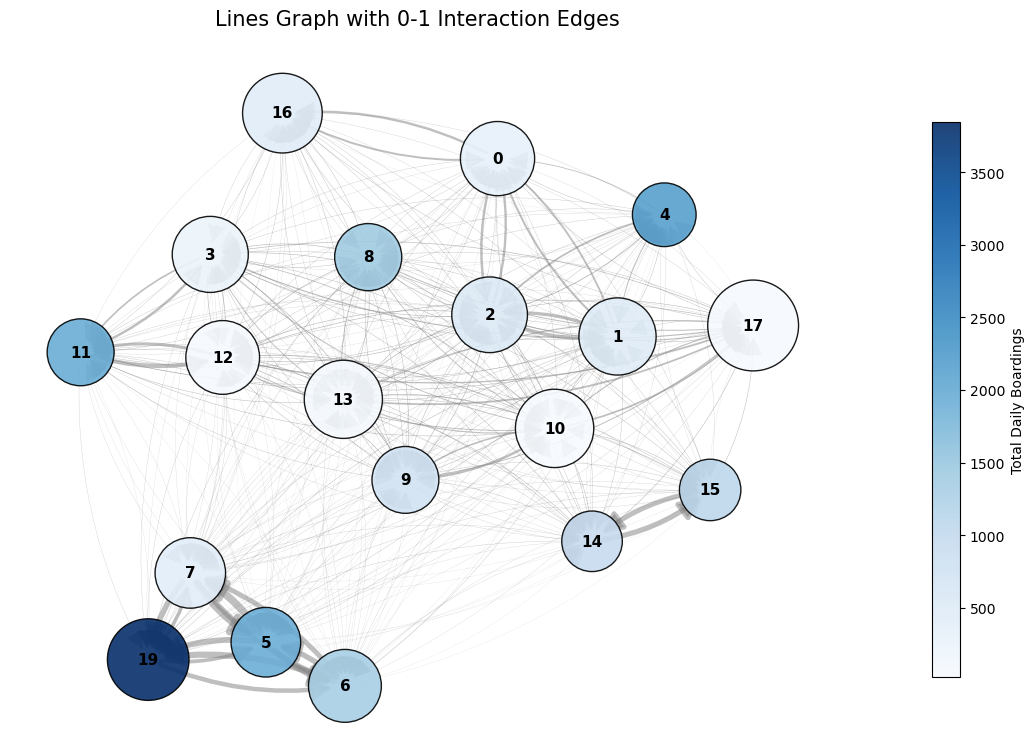

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Yönlü Çizgeyi Oluştur (Directed Graph)
G = nx.DiGraph()

# 3. Bulanık Mantıkla Belirlenen Ağırlıklı Kenarları Ekle
# weights: (Kaynak, Hedef, Bulanık Etki Ağırlığı)
# Önceki adımda hesapladığımız normalize edilmiş değerleri kullanıyoruz

# 2. Düğümleri Tanımla
# Daha hızlı ve temiz kenar oluşturma
MAX_LINES=20     #Deneme

edges = [(i, j, w[i, j]) for i in range(MAX_LINES)   
         for j in range(MAX_LINES)            
         if i != j and w[i, j] > 0] # Sadece ağırlığı olanları ekle

G.add_weighted_edges_from(edges)

# 2. Analiz: PageRank (TransitRank)
#ranks = nx.pagerank(G, alpha=0.85, weight='weight')
scaling_factor = 3000 # Boyutları belirginleştirmek için çarpan

# 3. Görselleştirme
fig, ax = plt.subplots(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42)

# 2. Kapasiteleri Tanımla
# Kapasiteleri görselde düğüm boyutu için kullanacağız

capacities = {i: LW1[i] for i in range(MAX_LINES)}

# Düğümleri Çiz
node_sizes = [PR[node] * scaling_factor for node in G.nodes()]
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                               node_color=[capacities[n] for n in G.nodes()], 
                               cmap=plt.cm.Blues, alpha=0.9, edgecolors="black")

# Kenarları Çiz
weights = [G[u][v]['weight'] * 100 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', 
                       arrowsize=30, alpha=0.5, connectionstyle='arc3,rad=0.15')

# Etiketler
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

# --- 4. BOYUT LEGENDİ EKLEME (KRİTİK KISIM) ---
# Temsili Rank değerleri seçiyoruz (Örn: 0.1, 0.4, 0.7)
#legend_ranks = [0.1, 0.4, 0.7]
#legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Rank: {r}',
#                          markerfacecolor='gray', markersize=np.sqrt(r * scaling_factor), 
#                          alpha=0.6) for r in legend_ranks]

# Legendi sağ üst köşeye ekle
#size_legend = ax.legend(handles=legend_elements, title="Hat Önem Derecesi (Rank)", 
#                        loc='upper right', labelspacing=2, borderpad=1.5, 
#                        frameon=True, fontsize=10)
#ax.add_artist(size_legend)

# 5. Renk Çubuğu (Kapasite İçin)
plt.colorbar(nodes, label='Total Daily Boardings', pad=0.1, shrink=0.8)

plt.title("Lines Graph with 0-1 Interaction Edges", pad=20, fontsize=15)
plt.axis('off')
plt.savefig(db_yolu+r"\LineRank_grafigi.png", dpi=300, bbox_inches='tight')
plt.show()

array([[1.        , 0.109375  , 0.13207547, ..., 0.        , 0.02272727,
        0.        ],
       [0.109375  , 1.        , 0.19444444, ..., 0.        , 0.03703704,
        0.        ],
       [0.13207547, 0.19444444, 1.        , ..., 0.        , 0.0625    ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.02272727, 0.03703704, 0.0625    , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]])